In [38]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import jaccard_score

torch.manual_seed(42)
np.random.seed(42)

import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
IMG_SIZE = 512
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 10
NUM_WORKERS = 4
NUM_SAMPLES = 5

IN_CHANNELS = 3
OUT_CHANNELS = 1

FEATURES = [32, 64, 128, 256]

SMOOTH = 1e-6

MODEL_PATH = "unet_baseline.pth"

In [22]:
PROCESSED_DIR = Path(r"C:\Users\tilak\OneDrive\Documents\Tilak Asodariya\AI ML\Epoch\CORES\Task-2\SubTask-1\processed")

TRAIN_DIR = PROCESSED_DIR / "train"
TRAIN_MASK_DIR = PROCESSED_DIR / "train_labels"

VAL_DIR = PROCESSED_DIR / "val"
VAL_MASK_DIR = PROCESSED_DIR / "val_labels"

TEST_DIR = PROCESSED_DIR / "test"
TEST_MASK_DIR = PROCESSED_DIR / "test_labels"

In [23]:
class RoadDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.images = sorted(self.image_dir.glob("*.png"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.mask_dir / img_path.name
        image = np.array(Image.open(img_path).convert("RGB"),dtype=np.float32)
        image /= 255.0
        mask = np.array(Image.open(mask_path),dtype=np.float32)
        mask = (mask > 127).astype(np.float32)
        image = torch.tensor(image).permute(2, 0, 1)
        mask = torch.tensor(mask).unsqueeze(0)
        return image, mask

In [24]:
train_ds = RoadDataset(TRAIN_DIR,TRAIN_MASK_DIR)
val_ds = RoadDataset(VAL_DIR,VAL_MASK_DIR)
test_ds = RoadDataset(TEST_DIR,TEST_MASK_DIR)

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)
test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False)

In [25]:
class CONV(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [26]:
class UNet(nn.Module):
    def __init__(self,in_channels=IN_CHANNELS,out_channels=OUT_CHANNELS,features=FEATURES):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        self.downs = nn.ModuleList()
        current_channels = in_channels
        for feature in features:
            self.downs.append(CONV(current_channels, feature))
            current_channels = feature

        # Bottleneck
        self.bottleneck = CONV(features[-1],features[-1] * 2)

        # Decoder
        self.ups = nn.ModuleList()
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2,feature,kernel_size=2,stride=2))
            self.ups.append(CONV(feature * 2,feature))
        
        self.final_conv = nn.Conv2d(features[0],out_channels,kernel_size=1)

    def forward(self, x):
        skip_connections = []
        
        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decoder
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)

In [27]:
class BCEDiceLoss(nn.Module):

    def __init__(self, smooth=SMOOTH):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred = torch.sigmoid(pred)
        pred = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice_score = (2 * intersection + self.smooth) / (pred.sum() +target.sum() +self.smooth)
        dice_loss = 1 - dice_score
        return bce_loss + dice_loss

In [28]:
@torch.no_grad()
def dice_score(pred, target, smooth=SMOOTH):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    
    return (2 * intersection + smooth) / (pred.sum() +target.sum() +smooth)

In [29]:
@torch.no_grad()
def iou_score(pred, target, smooth=SMOOTH):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = (pred.sum() +target.sum() -intersection)
    
    return (intersection + smooth) / (union + smooth)

In [30]:
model = UNet().to(DEVICE)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)

def trainer(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader,desc="Training",leave=False)
    for images, masks in pbar:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    pbar = tqdm(loader,desc="Validation",leave=False)
    for images, masks in pbar:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, masks)
        val_loss += loss.item()
        val_dice += dice_score(outputs,masks).item()
        val_iou += iou_score(outputs,masks).item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return (val_loss / len(loader),val_dice / len(loader),val_iou / len(loader))

In [31]:
train_losses = []
val_losses = []

val_dices = []
val_ious = []

best_dice = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")
    train_loss = trainer(model,train_loader,optimizer,criterion)
    val_loss, val_dice, val_iou = validate(model,val_loader,criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_dices.append(val_dice)
    val_ious.append(val_iou)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        best_epoch = epoch + 1
        torch.save(model.state_dict(),MODEL_PATH)
        print(f"Saved Model")

print(f"Best Epoch: {best_epoch}")
print(f"Best Dice: {best_dice:.4f}")


Epoch [1/10]


Train Loss: 1.4696 | Val Loss: 1.4347 | Dice: 0.3413 | IoU: 0.2058
Saved Model

Epoch [2/10]


Train Loss: 1.3117 | Val Loss: 1.2631 | Dice: 0.3996 | IoU: 0.2497
Saved Model

Epoch [3/10]


Train Loss: 1.2354 | Val Loss: 1.1586 | Dice: 0.4759 | IoU: 0.3122
Saved Model

Epoch [4/10]


Train Loss: 1.1615 | Val Loss: 1.0644 | Dice: 0.5653 | IoU: 0.3941
Saved Model

Epoch [5/10]


...

Train Loss: 1.0212 | Val Loss: 0.9036 | Dice: 0.6431 | IoU: 0.4741
Saved Model

Epoch [7/10]


Train Loss: 0.9616 | Val Loss: 0.8602 | Dice: 0.6685 | IoU: 0.5022
Saved Model

Epoch [8/10]


Train Loss: 0.9063 | Val Loss: 0.7855 | Dice: 0.6712 | IoU: 0.5052
Saved Model

Epoch [9/10]


Train Loss: 0.8547 | Val Loss: 0.7240 | Dice: 0.6933 | IoU: 0.5308
Saved Model

Epoch [10/10]


Train Loss: 0.8046 | Val Loss: 0.6816 | Dice: 0.7004 | IoU: 0.5393
Saved Model
Best Epoch: 10
Best Dice: 0.7004


In [34]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()


test_loss, test_dice, test_iou = validate(model,test_loader,criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU : {test_iou:.4f}")

Test Loss: 0.7168
Test Dice: 0.7245
Test IoU : 0.5690


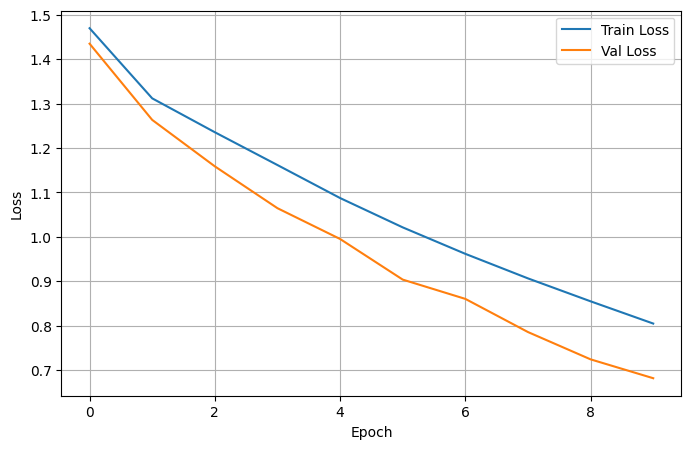

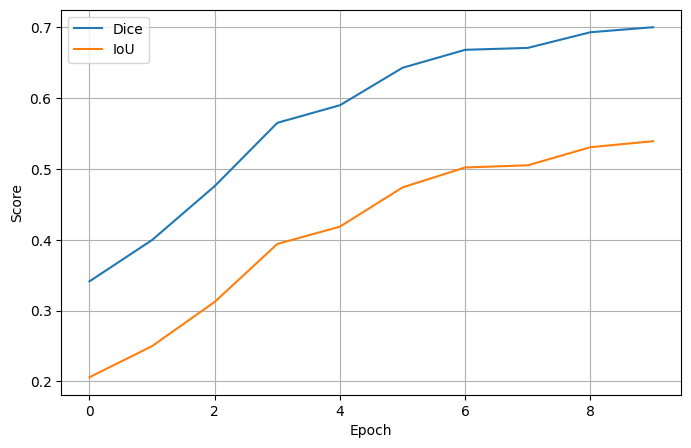

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(val_dices, label="Dice")
plt.plot(val_ious, label="IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

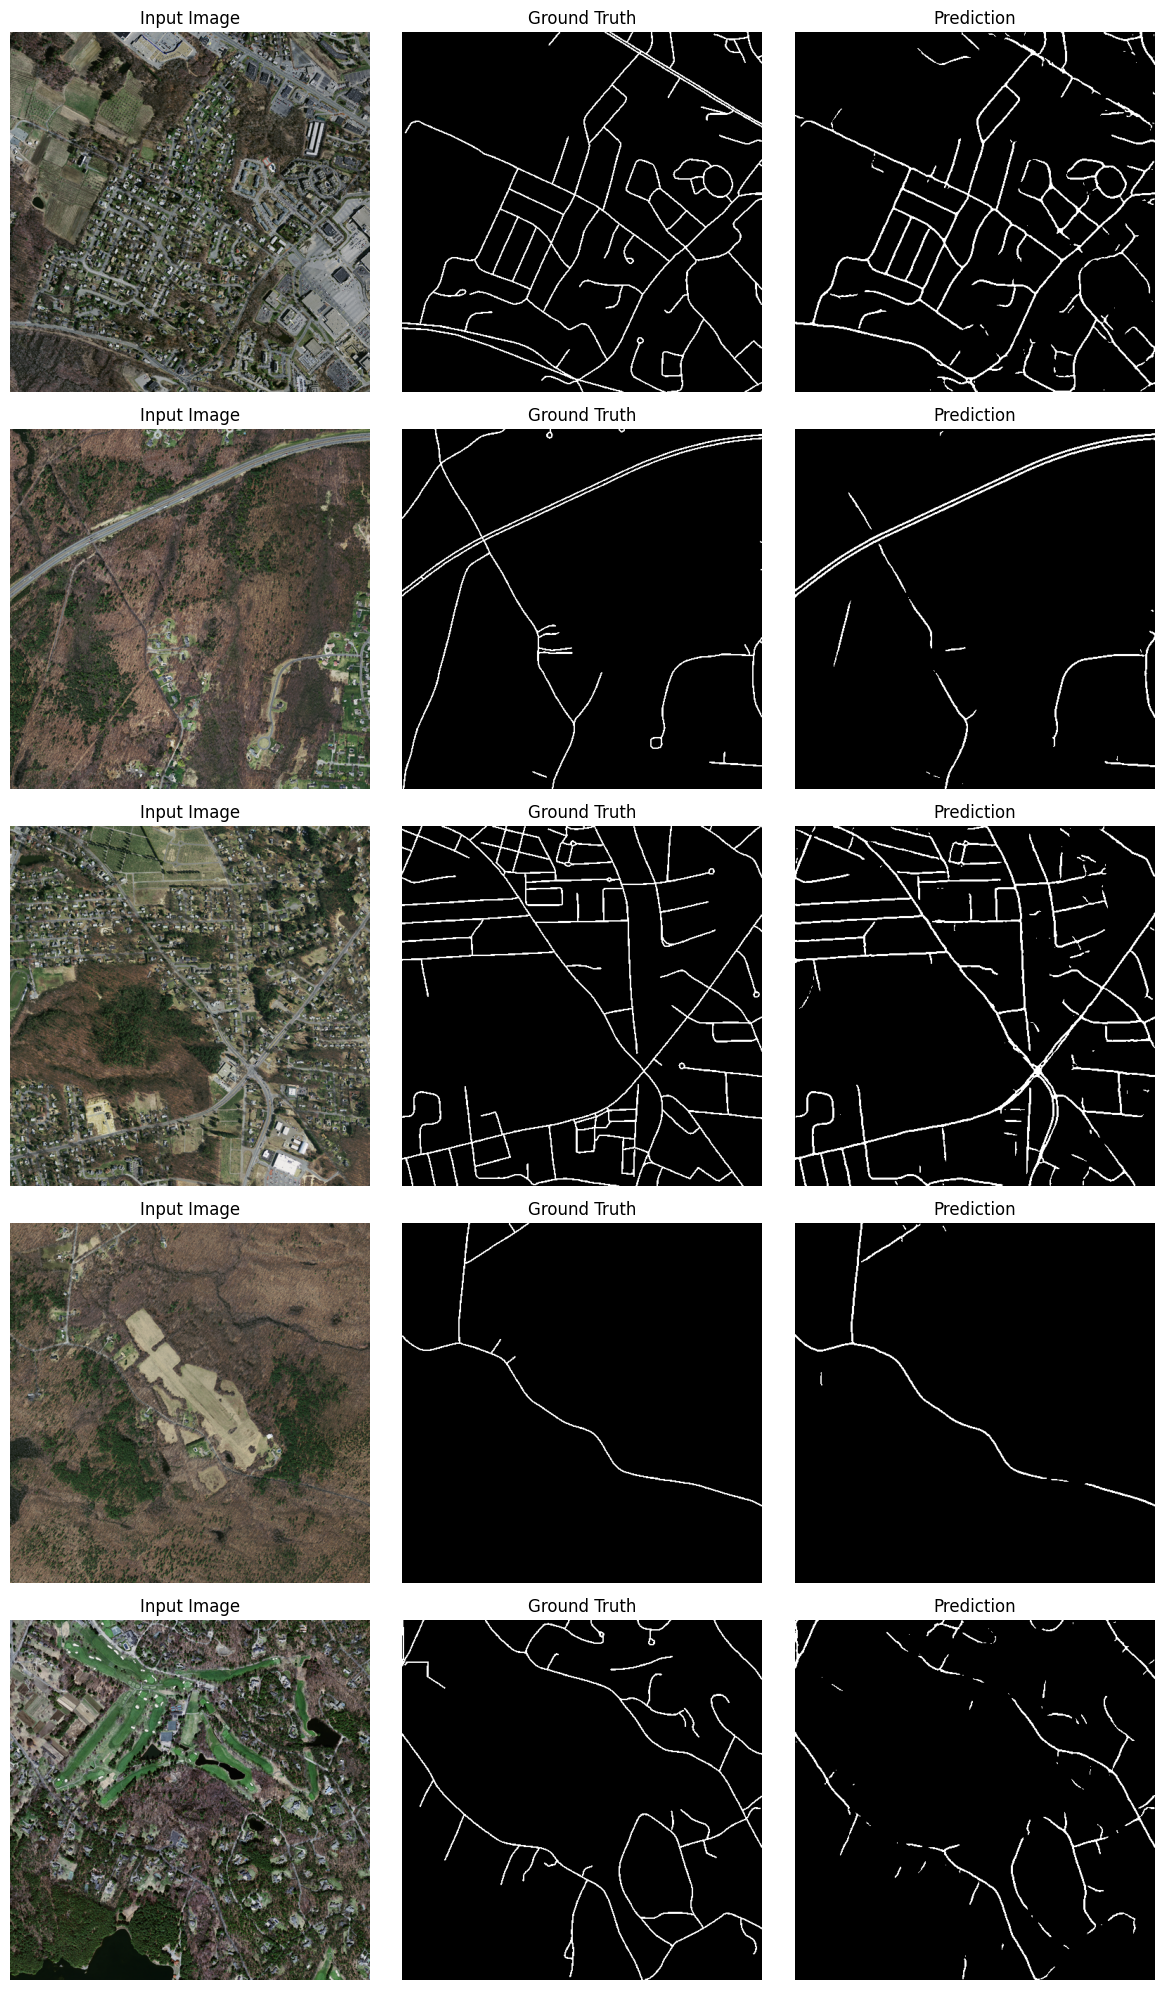

In [40]:
num_samples = NUM_SAMPLES

indices = random.sample(range(len(test_ds)),num_samples)
fig, axes = plt.subplots(num_samples,3,figsize=(12, 4 * num_samples))

with torch.no_grad():
    for row, idx in enumerate(indices):
        image, mask = test_ds[idx]
        pred = model(image.unsqueeze(0).to(DEVICE))
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

        image = image.permute(1, 2, 0).cpu().numpy()
        mask = mask.squeeze().cpu().numpy()
        pred = pred.squeeze().cpu().numpy()

        axes[row, 0].imshow(image)
        axes[row, 0].set_title("Input Image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred, cmap="gray")
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis("off")

plt.tight_layout()
plt.show()